### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [156]:
data = pd.read_csv('data/coupons.csv')

In [157]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [158]:
# investigate the data type
data.info()

# a count of missing values per column
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [159]:
## check the 'car' columns a little bit further
# what are the few values in the 'car' columns?
data['car'].value_counts()

# count, per row, how many of these five (containing NaN) columns are missing:
data[['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']].isna().sum(axis=1).value_counts()

0    12079
1      542
5       42
2       21
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [160]:
# drop the 'car' column 
data = data.drop(columns=['car'])

# drop the 42 rows that are missing all 5 columns 
data = data.dropna(subset=['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50'], thresh=1)

# fill the missing columns with its mode
cols = ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']
for col in cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# double check that there is no NaNs in the resulting data frame
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [161]:
# Using the .mean() command ignores trhe zero values, and so it give me the porportion of accepted coupons
data['Y'].mean()

np.float64(0.5680272108843537)

5. Use a bar plot to visualize the `coupon` column.

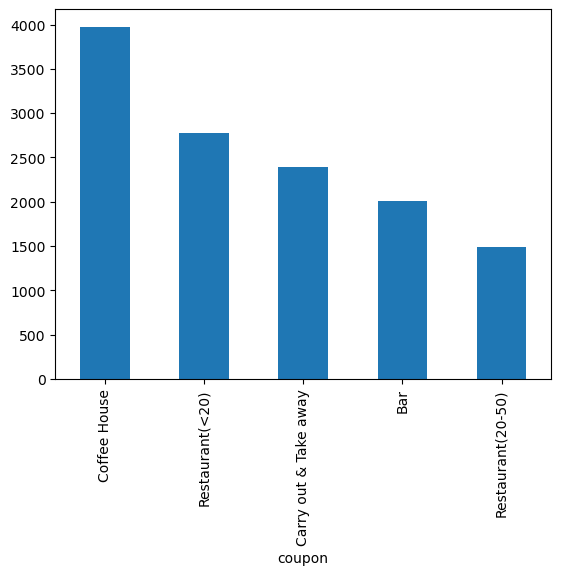

In [162]:
# use pandas to plot the data
data['coupon'].value_counts().plot(kind='bar')
plt.savefig('coupon-col-visual-pandas.png', bbox_inches='tight')


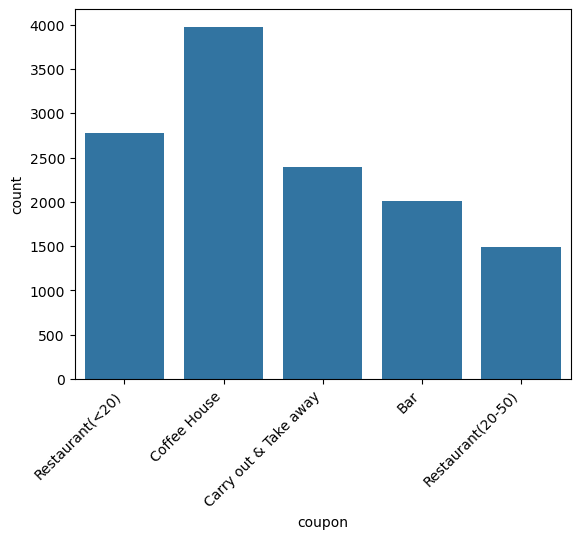

In [163]:
#use seaborn to plot the same data. SEaborn does the counting so no nned to add the .value_counts() command.
sns.countplot(data=data, x='coupon')
plt.xticks(rotation=45, ha='right')
plt.savefig('coupon-col-visual-sns.png', bbox_inches='tight')
plt.show()

6. Use a histogram to visualize the temperature column.

In [221]:
data.groupby('temperature')['Y'].mean()

temperature
30    0.531088
55    0.536292
80    0.599908
Name: Y, dtype: float64

In [222]:
data['temperature'].value_counts()

temperature
80    6496
55    3830
30    2316
Name: count, dtype: int64

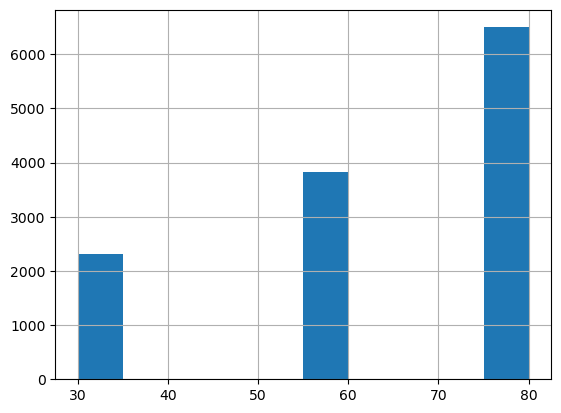

In [164]:
#Use pandas to plot the data 
data['temperature'].hist()
plt.savefig('temperature-visual-pandas.png', bbox_inches='tight')

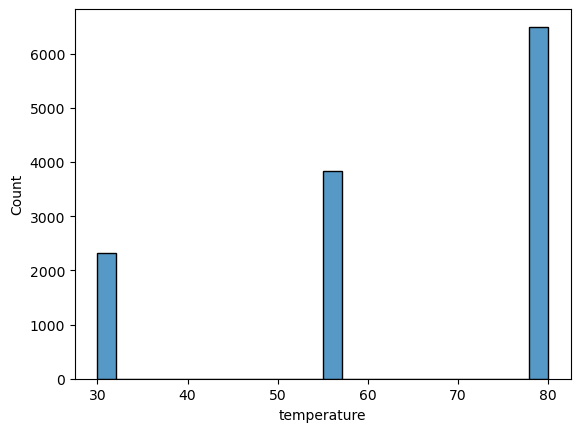

temperature
80    6496
55    3830
30    2316
Name: count, dtype: int64

In [165]:
# Use seaborn to plot the data
sns.histplot(data=data, x='temperature')
plt.savefig('temperature-visual-sns.png', bbox_inches='tight')
plt.show()
# what is the data actrually plotted?
data['temperature'].value_counts()

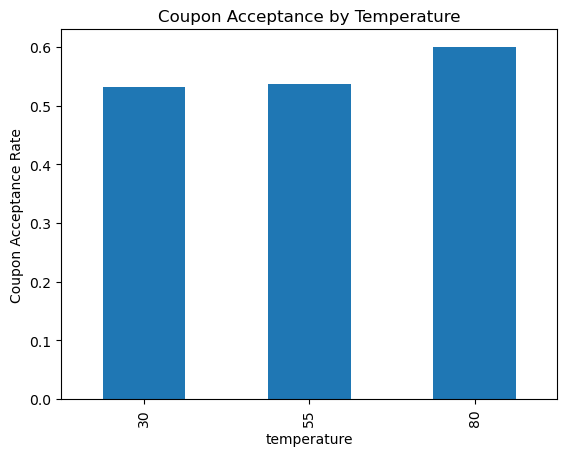

In [223]:
data.groupby('temperature')['Y'].mean().plot(kind='bar')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Coupon Acceptance by Temperature')
plt.savefig('temperature_acceptance.png', bbox_inches='tight')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [166]:
# check the exact spelling
data['coupon'].unique()

array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar',
       'Restaurant(20-50)'], dtype=object)

In [167]:
# Create a data frame containing only the data with the Bar coupon
bar_data = data[data['coupon'] == 'Bar']
bar_data.head()
bar_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2008 entries, 9 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           2008 non-null   object
 1   passanger             2008 non-null   object
 2   weather               2008 non-null   object
 3   temperature           2008 non-null   int64 
 4   time                  2008 non-null   object
 5   coupon                2008 non-null   object
 6   expiration            2008 non-null   object
 7   gender                2008 non-null   object
 8   age                   2008 non-null   object
 9   maritalStatus         2008 non-null   object
 10  has_children          2008 non-null   int64 
 11  education             2008 non-null   object
 12  occupation            2008 non-null   object
 13  income                2008 non-null   object
 14  Bar                   2008 non-null   object
 15  CoffeeHouse           2008 non-null   obje

2. What proportion of bar coupons were accepted?


In [168]:
#Using the .mean() command ignores trhe zero values, and so it gives me the porportion of accepted Bar coupons
bar_data['Y'].mean()

np.float64(0.40936254980079684)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [169]:
# check the correct spelling
data['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [170]:
# create 2 separate subgroup with frequent bar visitors and less frequent bar visitors 
bar_less = bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])]
bar_more = bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]

In [171]:
#calculate the acceptance rate of the less frequent bar visitors 
bar_less['Y'].mean()

np.float64(0.36981757877280264)

In [172]:
#calculate the acceptance rate of the less frequent bar visitors 
bar_more['Y'].mean()

np.float64(0.7688442211055276)

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [173]:
#create a boolean array witht the 2 conditions given
condition1 = bar_data['Bar'].isin(['1~3', '4~8', 'gt8']) #drivers who go to a bar more than once a month
condition2 = bar_data['age'].isin(['26', '31', '36', '41', '46', '50plus']) #are over the age of 25

#create a new subset with the 2 conditions being true
over25_frequent = bar_data[condition1 & condition2]
#create a new subset with the rest of the data
all_others = bar_data[~(condition1 & condition2)]

In [174]:
#calculate the acceptance rate of the frequent bar visitors over 25
over25_frequent['Y'].mean()

np.float64(0.6952380952380952)

In [175]:
#calculate the acceptance rate all other visitors 
all_others['Y'].mean()

np.float64(0.3337531486146096)

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [176]:
# check the correct spelling
data['passanger'].unique()

array(['Alone', 'Friend(s)', 'Kid(s)', 'Partner'], dtype=object)

In [177]:
# check the correct spelling
data['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [178]:
#create a boolean array witht the 2 conditions given
condition3 = bar_data['passanger'] != 'Kid(s)' #drivers who had passengers that were not a kid 
condition4 = bar_data['occupation'] != 'Farming Fishing & Forestry' #had occupations other than farming, fishing, or forestry.

#create a new subset with the 3 conditions being true
frequent_nokids_noFFF = bar_data[condition1 & condition3 & condition4]
#create a new subset with the rest of the data
all_others2 = bar_data[~(condition1 & condition3 & condition4)]

In [179]:
# calculate the acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid 
# and had occupations other than farming, fishing, or forestry.
frequent_nokids_noFFF['Y'].mean()

np.float64(0.7132486388384754)

In [180]:
#calculate the acceptance rate all other visitors 
all_others2['Y'].mean()

np.float64(0.29444063143445437)

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [181]:
# check the correct spelling
data['maritalStatus'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [182]:
# check the correct spelling
data['income'].unique()

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [183]:
# check the correct spelling
data['RestaurantLessThan20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)

In [184]:
#create a boolean array witht the 4 extra conditions given
condition5 = bar_data['maritalStatus'] != 'Widowed' #were not widowed
condition7 = bar_data['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']) #income is less than 50K
condition6 = bar_data['age'].isin(['26','21','below21']) #are under the age of 30
condition8 = bar_data['RestaurantLessThan20'].isin(['4~8','gt8']) #go to cheap restaurants more than 4 times a month 

# create the 2 dataframes with anyone who satisfies at least one of the three subgroups
combined = bar_data[(condition1 & condition3 & condition5) | (condition1 & condition6) | (condition8 & condition7)]
# create a new subset with the rest of the data
all_others3 = bar_data[~((condition1 & condition3 & condition5) | (condition1 & condition6) | (condition8 & condition7))]


In [185]:
#calculate the acceptance rate go to bars more than once a month, had passengers that were not a kid, and were not widowed OR
#go to bars more than once a month and are under the age of 30 OR
#go to cheap restaurants more than 4 times a month and income is less than 50K.
combined['Y'].mean()

np.float64(0.5889175257731959)

In [186]:
#calculate the acceptance rate of all other visitors 
all_others3['Y'].mean()

np.float64(0.2962662337662338)

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

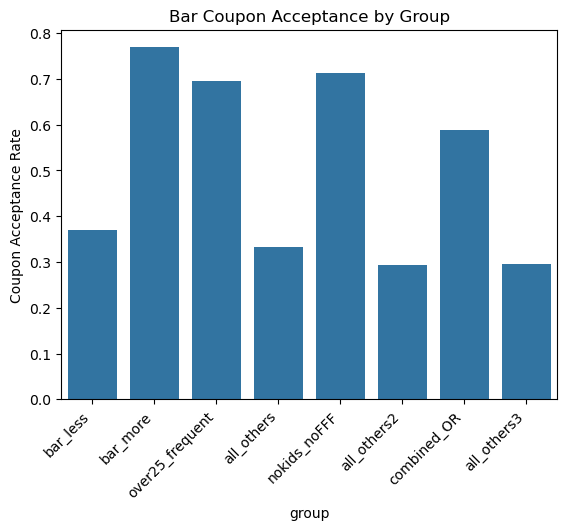

In [187]:
# plot a summary of the results calculated in the previous steps

summary = pd.DataFrame({
    'group': ['bar_less', 'bar_more', 'over25_frequent', 'all_others',
              'nokids_noFFF', 'all_others2', 'combined_OR', 'all_others3'],
    'acceptance_rate': [bar_less['Y'].mean(), bar_more['Y'].mean(),
                         over25_frequent['Y'].mean(), all_others['Y'].mean(),
                         frequent_nokids_noFFF['Y'].mean(), all_others2['Y'].mean(),
                         combined['Y'].mean(), all_others3['Y'].mean()]
})

sns.barplot(data=summary, x='group', y='acceptance_rate')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Bar Coupon Acceptance by Group')
plt.savefig('bar_habit_comparison.png', bbox_inches='tight')
plt.show()

In [188]:
# quick check of people under 30 vs. over 30, within the frequent bar visitors
frequent = bar_data[condition1]
frequent_under30 = frequent[frequent['age'].isin(['21','26','below21'])]
frequent_30plus = frequent[~frequent['age'].isin(['21','26','below21'])]

#calculate the rate of acceptance of that group over 30
frequent_30plus['Y'].mean()

np.float64(0.6414342629482072)

In [189]:
#calculate the rate of acceptance of that group under 30
frequent_under30['Y'].mean()

np.float64(0.7217391304347827)

In [190]:
# quick check of people with kids in the car vs. no kids in the car, within the frequent bar visitors
frequent_kids = frequent[frequent['passanger'] == 'Kid(s)']
frequent_nokids = frequent[frequent['passanger'] != 'Kid(s)']


In [191]:
#calculate the rate of acceptance of that group with kids
frequent_kids['Y'].mean()

np.float64(0.37777777777777777)

In [192]:
#calculate the rate of acceptance of that group with no kids
frequent_nokids['Y'].mean()

np.float64(0.7132486388384754)

### Hypothesis on bar coupon acceptance: 
Acceptance is driven mainly by existing habit: frequent bar-goers (>3x/month) accept at roughly double the rate of infrequent ones (77% vs. 34%), and this holds even controlling for age and other factors. Passenger context matters almost as much: even frequent bar-goers accept far less often with a kid in the car (38% vs. 71%). Age has a smaller, secondary effect (72% vs. 64% for under 30 vs. 30+ frequent bar-goers). In short: habit > passenger type > age.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Check coupon for coffee shop

In [193]:
# Create a data frame containing only the data with the coffee shop coupon
coffee_data = data[data['coupon'] == 'Coffee House']
coffee_data.head()
coffee_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3975 entries, 1 to 12681
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           3975 non-null   object
 1   passanger             3975 non-null   object
 2   weather               3975 non-null   object
 3   temperature           3975 non-null   int64 
 4   time                  3975 non-null   object
 5   coupon                3975 non-null   object
 6   expiration            3975 non-null   object
 7   gender                3975 non-null   object
 8   age                   3975 non-null   object
 9   maritalStatus         3975 non-null   object
 10  has_children          3975 non-null   int64 
 11  education             3975 non-null   object
 12  occupation            3975 non-null   object
 13  income                3975 non-null   object
 14  Bar                   3975 non-null   object
 15  CoffeeHouse           3975 non-null   obje

In [194]:
#Using the .mean() command ignores trhe zero values, and so it gives me the porportion of accepted coffee coupons
coffee_data['Y'].mean()

np.float64(0.49886792452830186)

In [195]:
# check the correct spelling
coffee_data['CoffeeHouse'].unique()

array(['never', 'less1', '4~8', '1~3', 'gt8'], dtype=object)

In [196]:
# create 2 separate subgroups with frequent coffee shop visitors and less frequent coffee shop visitors 
coffee_less = coffee_data[coffee_data['CoffeeHouse'].isin(['never', 'less1', '1~3'])]
coffee_more = coffee_data[coffee_data['CoffeeHouse'].isin(['4~8', 'gt8'])]

In [197]:
#calculate the acceptance rate of the less frequent coffee shop visitors 
coffee_less['Y'].mean()

np.float64(0.44878836833602587)

In [198]:
#calculate the acceptance rate of the more frequent coffee shop visitors 
coffee_more['Y'].mean()

np.float64(0.675)

In [199]:
# check the correct spelling
coffee_data['time'].unique()

array(['10AM', '2PM', '6PM', '7AM', '10PM'], dtype=object)

In [ ]:
#compare each time slot's acceptance rate individually
coffee_data.groupby('time')['Y'].mean()

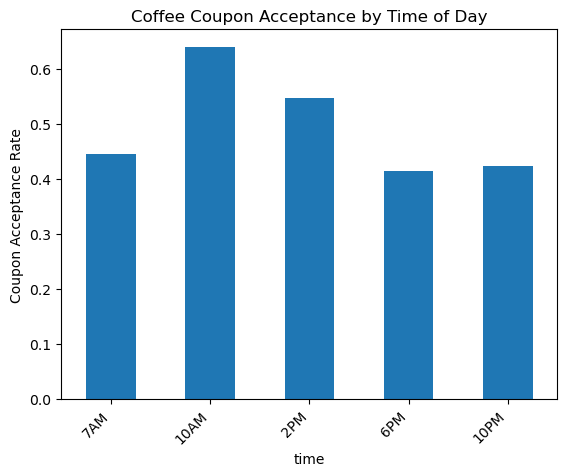

In [200]:
# plot the results to visualize the differences
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
coffee_data.groupby('time')['Y'].mean().reindex(time_order).plot(kind='bar')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Coffee Coupon Acceptance by Time of Day')
plt.xticks(rotation=45, ha='right')
plt.savefig('coffee_time_of_day.png', bbox_inches='tight')
plt.show()

In [201]:
#compare each age group's acceptance rate individually
coffee_data.groupby('age')['Y'].mean()

age
21         0.523322
26         0.516129
31         0.477492
36         0.467662
41         0.498452
46         0.513636
50plus     0.417132
below21    0.696774
Name: Y, dtype: float64

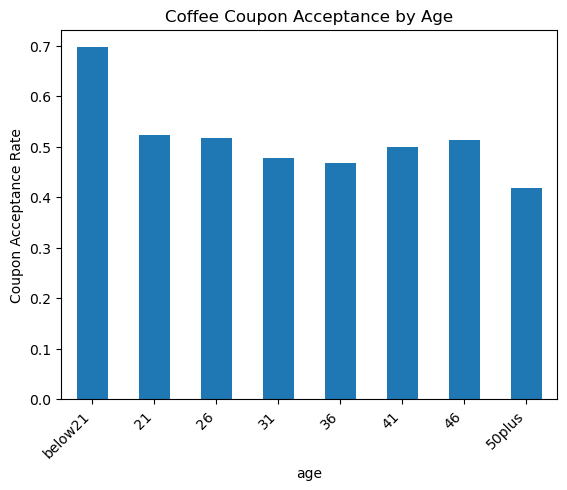

In [202]:
# plot the results to see the differences
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
coffee_data.groupby('age')['Y'].mean().reindex(age_order).plot(kind='bar')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Coffee Coupon Acceptance by Age')
plt.xticks(rotation=45, ha='right')
plt.savefig('coffee_age.png', bbox_inches='tight')
plt.show()

In [203]:
# check if the number of ppoeple in each group is significant enouigh to make a conclusion 
coffee_data['age'].value_counts()

age
21         879
26         837
31         622
50plus     537
36         402
41         323
46         220
below21    155
Name: count, dtype: int64

In [204]:
#compare each group by type of passenger
coffee_data.groupby('passanger')['Y'].mean()

passanger
Alone        0.437389
Friend(s)    0.597862
Kid(s)       0.485437
Partner      0.568106
Name: Y, dtype: float64

In [205]:
# check if the number of ppoeple in each group is significant enouigh to make a conclusion 
coffee_data['passanger'].value_counts()

passanger
Alone        2252
Friend(s)    1216
Partner       301
Kid(s)        206
Name: count, dtype: int64

In [206]:
# check the correct spelling
data['coupon'].unique()

array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar',
       'Restaurant(20-50)'], dtype=object)

### check coupon for cheap restaurant 

In [207]:
# create a new data frame with the data of interest
rest20_data = data[data['coupon'] == 'Restaurant(<20)']
rest20_data.head()
rest20_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2777 entries, 0 to 12678
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           2777 non-null   object
 1   passanger             2777 non-null   object
 2   weather               2777 non-null   object
 3   temperature           2777 non-null   int64 
 4   time                  2777 non-null   object
 5   coupon                2777 non-null   object
 6   expiration            2777 non-null   object
 7   gender                2777 non-null   object
 8   age                   2777 non-null   object
 9   maritalStatus         2777 non-null   object
 10  has_children          2777 non-null   int64 
 11  education             2777 non-null   object
 12  occupation            2777 non-null   object
 13  income                2777 non-null   object
 14  Bar                   2777 non-null   object
 15  CoffeeHouse           2777 non-null   obje

In [208]:
#Using the .mean() command ignores trhe zero values, and so it gives me the porportion of accepted coffee coupons
rest20_data['Y'].mean()

np.float64(0.7061577241627656)

In [209]:
# check the correct spelling
rest20_data['RestaurantLessThan20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)

In [210]:
# create 2 separate subgroups with frequent cheap restaurant visitors and less frequent cheap restaurants visitors 
rest20_less = rest20_data[rest20_data['RestaurantLessThan20'].isin(['never', 'less1', '1~3'])]
rest20_more = rest20_data[rest20_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])]

In [211]:
#calculate the acceptance rate of the less frequent cheap restaurants visitors 
rest20_less['Y'].mean()

np.float64(0.6915334517465956)

In [212]:
#calculate the acceptance rate of the less cheap restaurants visitors 
rest20_more['Y'].mean()

np.float64(0.7288602941176471)

In [213]:
# create the conditions to check the cceptance rate of frequent cheap restaurant visitors and their income
condition_freq = rest20_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])
condition_income = rest20_data['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'])

# create the new data frames of the subgroups
rest20_freq_lowincome = rest20_data[condition_freq & condition_income]
rest20_others = rest20_data[~(condition_freq & condition_income)]

In [214]:
# Calculate the rate of acceptance of the subgroup with low income
rest20_freq_lowincome['Y'].mean()

np.float64(0.7108910891089109)

In [215]:
# Calculate the rate of acceptance of the rest of the people
rest20_others['Y'].mean()

np.float64(0.7051056338028169)

In [216]:
#compare each time slot's acceptance rate individually
rest20_data.groupby('time')['Y'].mean()

time
10AM    0.708609
10PM    0.505376
2PM     0.811867
6PM     0.827078
7AM     0.582897
Name: Y, dtype: float64

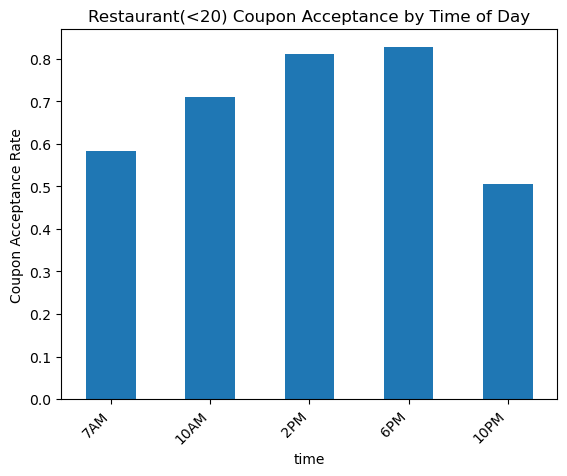

In [217]:
# plot the results to see the differences
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
rest20_data.groupby('time')['Y'].mean().reindex(time_order).plot(kind='bar')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Restaurant(<20) Coupon Acceptance by Time of Day')
plt.xticks(rotation=45, ha='right')
plt.savefig('cheapRest_time_of_day.png', bbox_inches='tight')
plt.show()

In [ ]:
#compare each type of passenger's acceptance rate individually
rest20_data.groupby('passanger')['Y'].mean()

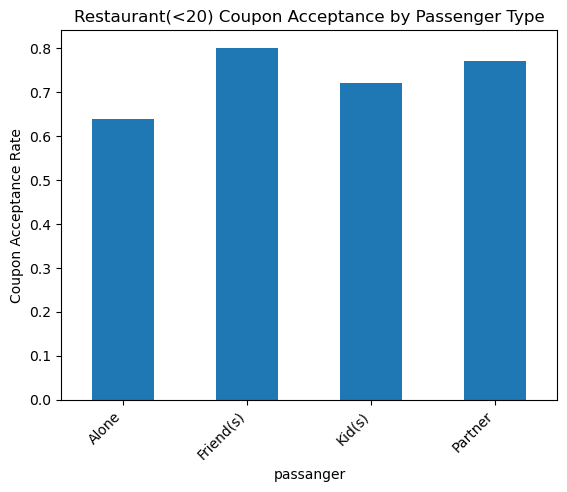

In [218]:
# plot the results to see the differences
rest20_data.groupby('passanger')['Y'].mean().plot(kind='bar')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Restaurant(<20) Coupon Acceptance by Passenger Type')
plt.xticks(rotation=45, ha='right')
plt.savefig('cheapRest_passengerType.png', bbox_inches='tight')
plt.show()